# 🧠 MNIST Image Denoising using Autoencoders

[![ForTheBadge built-with-love](http://ForTheBadge.com/images/badges/built-with-love.svg)](https://github.com/NvsYashwanth)

![](https://badgen.net/badge/Code/Python/blue?icon=https://simpleicons.org/icons/python.svg&labelColor=cyan&label) ![](https://badgen.net/badge/Library/Pytorch/blue?icon=https://simpleicons.org/icons/pytorch.svg&labelColor=cyan&label) ![](https://badgen.net/badge/Tools/numpy/blue?icon=https://upload.wikimedia.org/wikipedia/commons/1/1a/NumPy_logo.svg&labelColor=cyan&label) ![](https://badgen.net/badge/Tools/matplotlib/blue?icon=https://upload.wikimedia.org/wikipedia/en/5/56/Matplotlib_logo.svg&labelColor=cyan&label)

---

## 📖 Overview

Autoencoders learn to compress data into a compact latent representation and reconstruct it.  
Here we use them as **denoisers**: the input is a *noisy* image, the target is the *clean* original.

### Dataset folder structure expected
```
mnist_png/
├── training/
│   ├── 0/   *.png
│   ├── 1/   *.png
│   └── …    (2 – 9)
└── testing/
    ├── 0/   *.png
    └── …    (1 – 9)
```
👉 **Just upload / unzip your dataset so that the `mnist_png/` folder is in the same directory as this notebook, then run all cells.**

### Models implemented
| # | Model | Architecture | Key Feature |
|---|-------|-------------|-------------|
| 1 | **FFNN Autoencoder** | Fully-Connected | Simple baseline |
| 2 | **Transpose CNN Autoencoder** | Conv + ConvTranspose2d | Spatial awareness |
| 3 | **Upsampled CNN Autoencoder** ⭐ | Conv + Upsample + Conv | No checkerboard artifacts |

---

In [1]:

import os

for root, dirs, files in os.walk("/kaggle/input"):
    if "training" in dirs:
        print("Found:", root)

Found: /kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png


## 📦 Step 1 — Install & Verify Required Packages

In [2]:
import subprocess, sys

PKGS = ["torch", "torchvision", "numpy", "pandas",
        "matplotlib", "scikit-learn", "tqdm", "Pillow"]

print("Installing / verifying packages …")
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "--quiet", *PKGS],
    capture_output=True, text=True
)

# Only show real errors – skip RAPIDS/CUDA resolver noise
SKIP_KEYWORDS = [
    "dependency resolver", "dask-cuda", "numba-cuda", "cuml",
    "cudf", "ucxx", "distributed-ucxx", "cuda-core", "numba",
    "incompatible", "behaviour", "WARNING"
]
real_errors = [
    ln for ln in result.stderr.splitlines()
    if ln.strip() and not any(k in ln for k in SKIP_KEYWORDS)
]
if real_errors:
    print("⚠️  Unexpected messages:")
    print("\n".join(real_errors))
else:
    print("✅  All packages installed (RAPIDS conflict warnings safely ignored).")

# Smoke-test imports
import importlib
checks = {"torch": "torch", "torchvision": "torchvision",
          "numpy": "numpy", "PIL": "Pillow",
          "matplotlib": "matplotlib", "sklearn": "scikit-learn",
          "tqdm": "tqdm"}
print()
all_ok = True
for mod, pkg in checks.items():
    try:
        m   = importlib.import_module(mod)
        ver = getattr(m, "__version__", "n/a")
        print(f"  ✔  {pkg:<18} {ver}")
    except ImportError:
        print(f"  ✘  {pkg}  — import FAILED")
        all_ok = False

print()
print("🎉 Environment ready!" if all_ok else "❌ Fix import errors above before continuing.")

Installing / verifying packages …
✅  All packages installed (RAPIDS conflict warnings safely ignored).

  ✔  torch              2.10.0+cpu
  ✔  torchvision        0.25.0+cpu
  ✔  numpy              2.4.6
  ✔  Pillow             11.3.0
  ✔  matplotlib         3.10.0
  ✔  scikit-learn       1.6.1
  ✔  tqdm               4.67.3

🎉 Environment ready!


## 📂 Step 2 — Point to Your Uploaded Dataset

Set `DATASET_ROOT` to wherever `mnist_png/` lives.  
Default assumes it is **next to this notebook** (most common case).

In [3]:
import os

# ── CHANGE THIS if your dataset is somewhere else ─────────────────────────────
DATASET_ROOT = "/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png"          # folder containing training/ and testing/
# Examples:
#   DATASET_ROOT = "/content/mnist_png"          # Colab after upload
#   DATASET_ROOT = "/kaggle/working/mnist_png"   # Kaggle notebook
#   DATASET_ROOT = "MNIST Dataset/mnist_png"     # if there's a parent folder
# ─────────────────────────────────────────────────────────────────────────────

TRAIN_DIR = os.path.join(DATASET_ROOT, "training")
TEST_DIR  = os.path.join(DATASET_ROOT, "testing")

assert os.path.isdir(TRAIN_DIR), (
    f"❌  Training directory not found: {TRAIN_DIR}\n"
    "    → Set DATASET_ROOT correctly above."
)
assert os.path.isdir(TEST_DIR), (
    f"❌  Testing directory not found: {TEST_DIR}\n"
    "    → Set DATASET_ROOT correctly above."
)

print(f"✅  Dataset root  : {os.path.abspath(DATASET_ROOT)}")
print(f"   Training path : {TRAIN_DIR}")
print(f"   Testing  path : {TEST_DIR}")

✅  Dataset root  : /kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png
   Training path : /kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training
   Testing  path : /kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/testing


## 🔍 Step 3 — Explore Folder Structure & Count Images

In [4]:
def count_images(split_dir):
    """Return {class_label: image_count} for a split directory."""
    counts = {}
    for cls in sorted(os.listdir(split_dir)):
        cls_path = os.path.join(split_dir, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len([
                f for f in os.listdir(cls_path)
                if f.lower().endswith((".png", ".jpg", ".jpeg"))
            ])
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

print("Digit   Training   Testing")
print("-" * 28)
for digit in sorted(train_counts.keys()):
    print(f"  {digit}      {train_counts[digit]:>6,}   {test_counts.get(digit, 0):>6,}")
print("-" * 28)
print(f"  Total  {sum(train_counts.values()):>6,}   {sum(test_counts.values()):>6,}")

Digit   Training   Testing
----------------------------
  0       5,923      980
  1       6,742    1,135
  2       5,958    1,032
  3       6,131    1,010
  4       5,842      982
  5       5,421      892
  6       5,918      958
  7       6,265    1,028
  8       5,851      974
  9       5,949    1,009
----------------------------
  Total  60,000   10,000


## 📚 Step 4 — Import Libraries & Global Config

In [5]:
import os, math, warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn            as nn
import torch.optim         as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device  : {device}")
if torch.cuda.is_available():
    print(f"   GPU     : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"   PyTorch : {torch.__version__}")

🖥️  Device  : cpu
   PyTorch : 2.10.0+cpu


## 🗃️ Step 5 — Load PNG Images into NumPy Arrays

We walk every `digit/` sub-folder, open each `.png` with Pillow, convert to grayscale,  
resize to **28 × 28** (already the right size for MNIST), and normalise pixels to **[0, 1]**.

In [6]:
def load_png_split(split_dir, img_size=28):
    """
    Walk split_dir / {0..9} / *.png  and return:
        images  : float32 ndarray  shape (N, 784)   values in [0,1]
        labels  : int32   ndarray  shape (N,)
    """
    images, labels = [], []

    class_dirs = sorted(
        d for d in os.listdir(split_dir)
        if os.path.isdir(os.path.join(split_dir, d))
    )

    for cls in class_dirs:
        cls_path = os.path.join(split_dir, cls)
        img_files = sorted(
            f for f in os.listdir(cls_path)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        )
        for fname in img_files:
            fpath = os.path.join(cls_path, fname)
            img   = Image.open(fpath).convert("L")          # grayscale
            if img.size != (img_size, img_size):
                img = img.resize((img_size, img_size), Image.LANCZOS)
            arr = np.array(img, dtype=np.float32) / 255.0   # [0,1]
            images.append(arr.ravel())                       # flatten → (784,)
            labels.append(int(cls))

    images = np.stack(images, axis=0)   # (N, 784)
    labels = np.array(labels, dtype=np.int32)
    return images, labels


print("Loading training images …")
train_images, train_labels = load_png_split(TRAIN_DIR)
print(f"  Done → {train_images.shape}  labels {train_labels.shape}")

print("Loading testing  images …")
test_images,  test_labels  = load_png_split(TEST_DIR)
print(f"  Done → {test_images.shape}  labels {test_labels.shape}")

print(f"\nPixel range : [{train_images.min():.3f}, {train_images.max():.3f}]")

Loading training images …
  Done → (60000, 784)  labels (60000,)
Loading testing  images …
  Done → (10000, 784)  labels (10000,)

Pixel range : [0.000, 1.000]


## 🖼️ Step 6 — Visualise Sample Images (Clean vs Noisy)

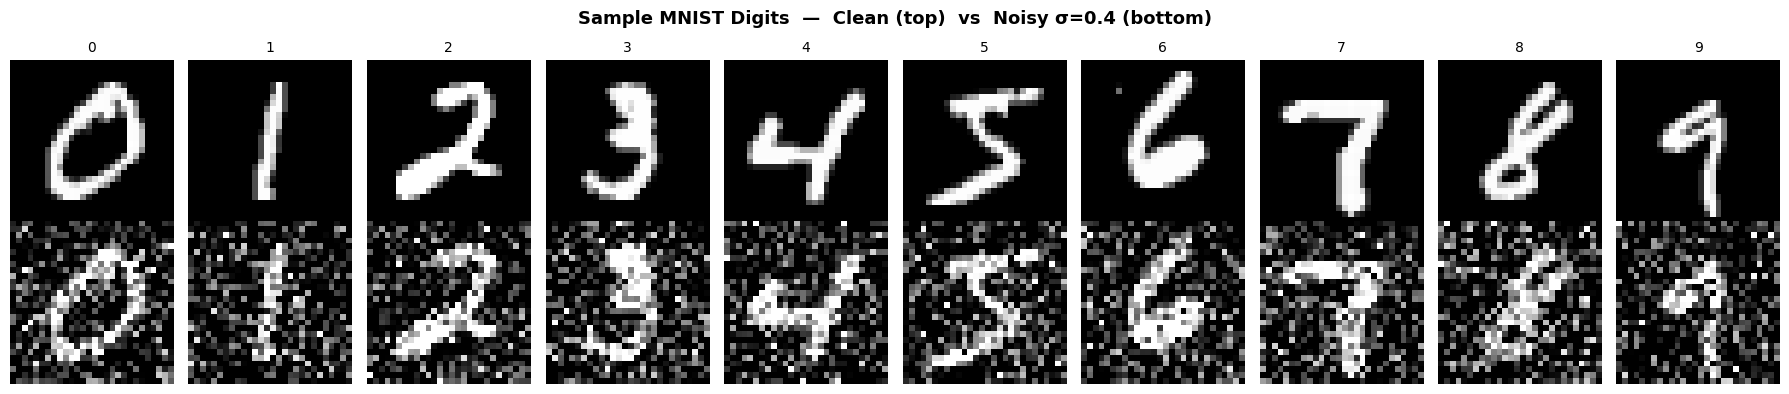

Saved → sample_digits.png


In [7]:
rng = np.random.default_rng(SEED)

fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle("Sample MNIST Digits  —  Clean (top)  vs  Noisy σ=0.4 (bottom)",
             fontsize=13, fontweight="bold")

for digit in range(10):
    idx = np.where(train_labels == digit)[0][0]
    img = train_images[idx].reshape(28, 28)

    # ── Clean ──────────────────────────────────────────
    axes[0, digit].imshow(img, cmap="gray", vmin=0, vmax=1)
    axes[0, digit].set_title(str(digit), fontsize=10)
    axes[0, digit].axis("off")

    # ── Noisy ──────────────────────────────────────────
    noisy = np.clip(
        img + rng.normal(0, 0.4, img.shape).astype(np.float32), 0, 1
    )
    axes[1, digit].imshow(noisy, cmap="gray", vmin=0, vmax=1)
    axes[1, digit].axis("off")

axes[0, 0].set_ylabel("Clean", fontsize=10, fontweight="bold")
axes[1, 0].set_ylabel("Noisy", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("sample_digits.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → sample_digits.png")

## 🏗️ Step 7 — Custom Dataset & DataLoaders

In [8]:
class MNISTNoisyDataset(Dataset):
    """
    PyTorch Dataset built from pre-loaded NumPy arrays.

    Each __getitem__ call:
      1. Samples fresh Gaussian noise ~ N(0, noise_factor)
      2. Clips to [0, 1]
      3. Returns (noisy_tensor, clean_tensor [, label])

    Parameters
    ----------
    images       : float32 ndarray (N, 784)  values in [0,1]
    labels       : int ndarray (N,) or None
    noise_factor : Gaussian std-dev  (0 = no noise)
    flat         : True  → tensors (784,)       for FFNN
                   False → tensors (1, 28, 28)  for CNN
    """
    def __init__(self, images, labels=None, noise_factor=0.4, flat=True):
        self.images       = images
        self.labels       = labels
        self.noise_factor = noise_factor
        self.flat         = flat

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        clean = self.images[idx].copy()                           # (784,) float32
        noise = np.random.normal(0, self.noise_factor,
                                 clean.shape).astype(np.float32)
        noisy = np.clip(clean + noise, 0.0, 1.0)

        clean_t = torch.from_numpy(clean)
        noisy_t = torch.from_numpy(noisy)

        if not self.flat:                                         # CNN: (1,28,28)
            clean_t = clean_t.view(1, 28, 28)
            noisy_t = noisy_t.view(1, 28, 28)

        if self.labels is not None:
            return noisy_t, clean_t, int(self.labels[idx])
        return noisy_t, clean_t


# ── Global hyper-parameters ───────────────────────────────────────────────────
NOISE_FACTOR = 0.4
BATCH_SIZE   = 128
EPOCHS       = 20
LR           = 1e-3
VAL_SIZE     = 12_000    # held-out from training set (48k train / 12k val)

print("Hyper-parameters")
print(f"  Noise factor  : {NOISE_FACTOR}")
print(f"  Batch size    : {BATCH_SIZE}")
print(f"  Epochs        : {EPOCHS}")
print(f"  Learning rate : {LR}")
print(f"  Val set size  : {VAL_SIZE:,}")

Hyper-parameters
  Noise factor  : 0.4
  Batch size    : 128
  Epochs        : 20
  Learning rate : 0.001
  Val set size  : 12,000


In [9]:
def make_loaders(flat=True, noise_factor=NOISE_FACTOR, batch_size=BATCH_SIZE):
    """Return (train_loader, val_loader, test_loader)."""
    full_train = MNISTNoisyDataset(train_images, train_labels,
                                   noise_factor=noise_factor, flat=flat)
    test_ds    = MNISTNoisyDataset(test_images,  test_labels,
                                   noise_factor=noise_factor, flat=flat)

    n_val   = min(VAL_SIZE, len(full_train) // 5)   # safe guard
    n_train = len(full_train) - n_val
    train_ds, val_ds = random_split(
        full_train, [n_train, n_val],
        generator=torch.Generator().manual_seed(SEED)
    )

    kw = dict(num_workers=0, pin_memory=(device.type == "cuda"))
    train_ld = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  **kw)
    val_ld   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, **kw)
    test_ld  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, **kw)

    print(f"  Train : {n_train:>6,} samples  →  {len(train_ld):>3} batches")
    print(f"  Val   : {n_val:>6,} samples  →  {len(val_ld):>3} batches")
    print(f"  Test  : {len(test_ds):>6,} samples  →  {len(test_ld):>3} batches")
    return train_ld, val_ld, test_ld


print("── Flat loaders (FFNN) ──")
train_ld_flat, val_ld_flat, test_ld_flat = make_loaders(flat=True)

print("\n── CNN loaders ──")
train_ld_cnn, val_ld_cnn, test_ld_cnn   = make_loaders(flat=False)

── Flat loaders (FFNN) ──
  Train : 48,000 samples  →  375 batches
  Val   : 12,000 samples  →   94 batches
  Test  : 10,000 samples  →   79 batches

── CNN loaders ──
  Train : 48,000 samples  →  375 batches
  Val   : 12,000 samples  →   94 batches
  Test  : 10,000 samples  →   79 batches


## ⚙️ Step 8 — Weight Initialisation

In [10]:
def init_weights(m):
    """
    Linear      : weight ~ N(0, 1/√fan_in),  bias = 0
    Conv        : Kaiming Normal (fan_out / ReLU)
    BatchNorm   : weight = 1,  bias = 0
    """
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, 0.0, 1.0 / math.sqrt(m.in_features))
        nn.init.zeros_(m.bias)
    elif isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.ones_(m.weight)
        nn.init.zeros_(m.bias)

print("✅ init_weights defined.")

✅ init_weights defined.


## 🏋️ Step 9 — Training & Evaluation Loop

In [11]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total = 0.0
    for batch in loader:
        noisy, clean = batch[0].to(device), batch[1].to(device)
        optimizer.zero_grad()
        loss = criterion(model(noisy), clean)
        loss.backward()
        optimizer.step()
        total += loss.item() * noisy.size(0)
    return total / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total = 0.0
    for batch in loader:
        noisy, clean = batch[0].to(device), batch[1].to(device)
        total += criterion(model(noisy), clean).item() * noisy.size(0)
    return total / len(loader.dataset)


def train_model(model, train_ld, val_ld, epochs=EPOCHS, lr=LR, name="Model"):
    """
    Full training loop with:
      - Adam optimiser
      - ReduceLROnPlateau (patience=3, factor=0.5)
      - Best-weight checkpointing by val MSE

    Returns (trained_model, history_dict)
    """
    model     = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode="min", factor=0.5,
                    patience=3)

    history    = {"train": [], "val": []}
    best_val   = float("inf")
    best_state = None

    n_params = sum(p.numel() for p in model.parameters())
    print(f"\n{'═'*64}")
    print(f"  {name}")
    print(f"  Trainable parameters : {n_params:,}")
    print(f"{'═'*64}")

    pbar = tqdm(range(1, epochs + 1), desc="Epochs", unit="ep", ncols=76)
    for epoch in pbar:
        tr  = train_epoch(model, train_ld, criterion, optimizer)
        val = evaluate(model, val_ld, criterion)
        scheduler.step(val)

        history["train"].append(tr)
        history["val"].append(val)

        is_best = val < best_val
        if is_best:
            best_val   = val
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        pbar.set_postfix(tr=f"{tr:.5f}", val=f"{val:.5f}",
                         best="✓" if is_best else " ")

    model.load_state_dict(best_state)
    print(f"\n  Best Val MSE : {best_val:.6f}")
    return model, history


print("✅ Training helpers defined.")

✅ Training helpers defined.


## 📊 Step 10 — Visualisation Helpers

In [12]:
def plot_loss(history, name="Model"):
    ep = range(1, len(history["train"]) + 1)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(ep, history["train"], "b-o", ms=4, label="Train MSE")
    ax.plot(ep, history["val"],   "r-o", ms=4, label="Val   MSE")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
    ax.set_title(f"{name} — Loss Curves", fontweight="bold")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    fname = name.replace(" ", "_").lower() + "_loss.png"
    plt.savefig(fname, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {fname}")


@torch.no_grad()
def show_denoising(model, loader, n=10, name="Model", flat=True):
    model.eval()
    batch = next(iter(loader))
    noisy = batch[0][:n].to(device)
    clean = batch[1][:n].cpu()
    recon = model(noisy).cpu()
    noisy = noisy.cpu()

    fig, axes = plt.subplots(3, n, figsize=(18, 5))
    fig.suptitle(f"{name} — Denoising Results", fontsize=13, fontweight="bold")
    for r, (imgs, title) in enumerate([
        (noisy, "Noisy Input"), (recon, "Reconstructed"), (clean, "Clean Target")
    ]):
        for c in range(n):
            img = imgs[c].view(28, 28) if flat else imgs[c].squeeze(0)
            axes[r, c].imshow(img.numpy(), cmap="gray", vmin=0, vmax=1)
            axes[r, c].axis("off")
        axes[r, 0].set_ylabel(title, fontsize=10, fontweight="bold")

    plt.tight_layout()
    fname = name.replace(" ", "_").lower() + "_results.png"
    plt.savefig(fname, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {fname}")


print("✅ Visualisation helpers defined.")

✅ Visualisation helpers defined.


---
# 🔬 Model 1 — FFNN Autoencoder

```
Encoder :  784 ──► 256 ──► 128 ──► 64   (ReLU)
Decoder :   64 ──► 128 ──► 256 ──► 784  (ReLU → Sigmoid)
```

- Flattened input (ignores spatial structure)
- Sigmoid output → pixels ∈ [0, 1]
- MSELoss for pixel-level regression

In [13]:
class FFNNAutoencoder(nn.Module):
    """
    Model 1 — Fully-Connected Autoencoder.
    Input / output : (batch, 784)
    Bottleneck     : (batch, 64)
    """
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU(True),
            nn.Linear(256, 128), nn.ReLU(True),
            nn.Linear(128,  64), nn.ReLU(True),
        )
        self.decoder = nn.Sequential(
            nn.Linear( 64, 128), nn.ReLU(True),
            nn.Linear(128, 256), nn.ReLU(True),
            nn.Linear(256, 784), nn.Sigmoid(),
        )
        self.apply(init_weights)

    def encode(self, x): return self.encoder(x)
    def decode(self, z): return self.decoder(z)
    def forward(self, x): return self.decode(self.encode(x))


m1 = FFNNAutoencoder()
print(m1)
print(f"\nParameters : {sum(p.numel() for p in m1.parameters()):,}")
# shape check
assert m1(torch.zeros(2, 784)).shape == (2, 784)
print("Shape check ✓  (2,784) → (2,784)")

FFNNAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)

Parameters : 484,944
Shape check ✓  (2,784) → (2,784)


In [14]:
m1, hist1 = train_model(m1, train_ld_flat, val_ld_flat,
                         name="Model 1: FFNN Autoencoder")


════════════════════════════════════════════════════════════════
  Model 1: FFNN Autoencoder
  Trainable parameters : 484,944
════════════════════════════════════════════════════════════════


Epochs:   0%|                                        | 0/20 [00:00<?, ?ep/s]


  Best Val MSE : 0.013487


In [15]:
crit    = nn.MSELoss()
m1_test = evaluate(m1, test_ld_flat, crit)
print(f"Model 1  Test MSE : {m1_test:.6f}")

Model 1  Test MSE : 0.013103


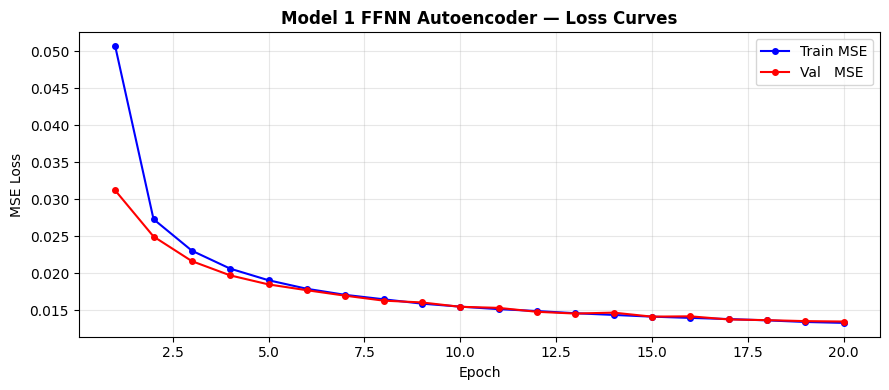

  Saved → model_1_ffnn_autoencoder_loss.png


In [16]:
plot_loss(hist1, "Model 1 FFNN Autoencoder")

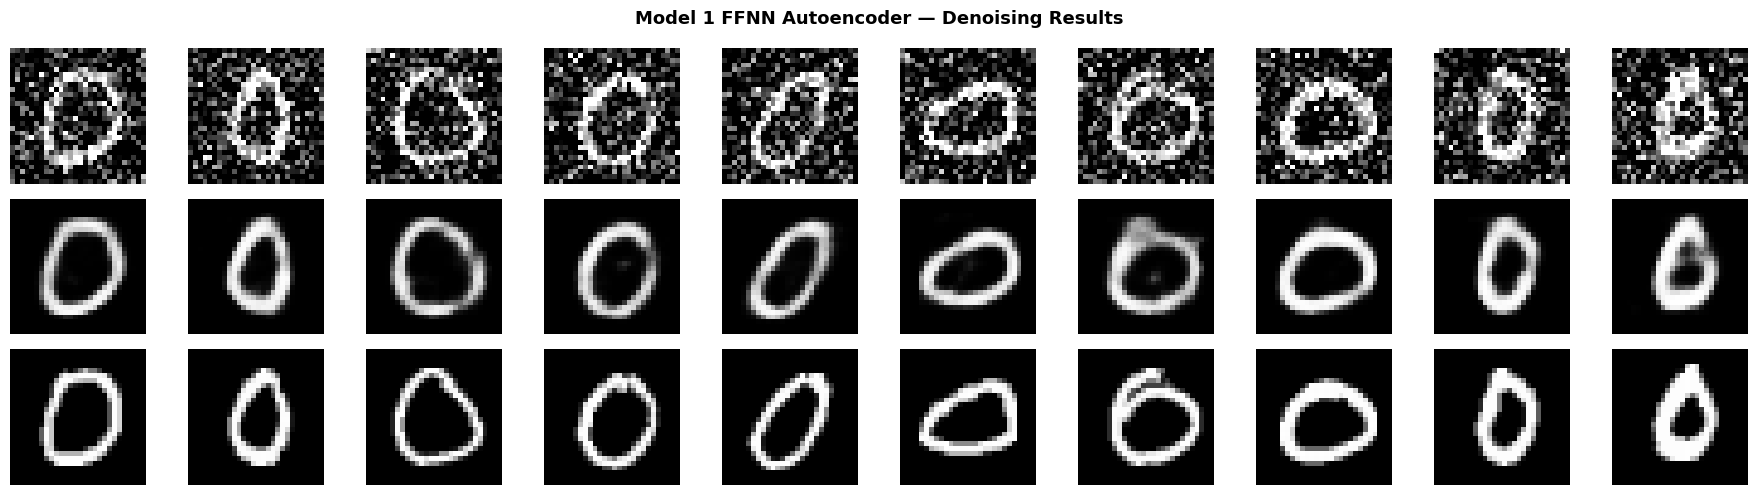

  Saved → model_1_ffnn_autoencoder_results.png


In [17]:
show_denoising(m1, test_ld_flat,
               name="Model 1 FFNN Autoencoder", flat=True)

---
# 🔬 Model 2 — Transpose CNN Autoencoder

```
Encoder : (1,28,28) ─Conv─► (16,14,14) ─Conv─► (32,7,7) ─Conv1×1─► (4,7,7)
Decoder : (4, 7, 7) ─ConvT► (16,14,14) ─ConvT►                 (1,28,28) ─Sigmoid
```

> ⚠️  `ConvTranspose2d` may introduce **checkerboard artifacts** — see Model 3 for the fix.

In [18]:
class TransposeCNNAutoencoder(nn.Module):
    """
    Model 2 — CNN Autoencoder with ConvTranspose2d decoder.
    Input / output : (batch, 1, 28, 28)
    Bottleneck     : (batch, 4,  7,  7)  =  196 values
    """
    def __init__(self):
        super().__init__()
        # Encoder: 28 → 14 → 7
        self.encoder = nn.Sequential(
            nn.Conv2d(1,  16, 3, stride=2, padding=1),    # (1,28,28)→(16,14,14)
            nn.BatchNorm2d(16), nn.ReLU(True),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),    # (16,14,14)→(32,7,7)
            nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32,  4, 1),                         # bottleneck (32,7,7)→(4,7,7)
            nn.ReLU(True),
        )
        # Decoder: 7 → 14 → 28
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(4,  32, 1),
            nn.BatchNorm2d(32), nn.ReLU(True),
            nn.ConvTranspose2d(32, 16, 3, stride=2,
                               padding=1, output_padding=1),   # 7→14
            nn.BatchNorm2d(16), nn.ReLU(True),
            nn.ConvTranspose2d(16,  1, 3, stride=2,
                               padding=1, output_padding=1),   # 14→28
            nn.Sigmoid(),
        )
        self.apply(init_weights)

    def encode(self, x): return self.encoder(x)
    def decode(self, z): return self.decoder(z)
    def forward(self, x): return self.decode(self.encode(x))


m2    = TransposeCNNAutoencoder()
dummy = torch.zeros(2, 1, 28, 28)
print(f"Input  : {dummy.shape}")
print(f"Latent : {m2.encode(dummy).shape}")
print(f"Output : {m2(dummy).shape}")
print(f"Params : {sum(p.numel() for p in m2.parameters()):,}")
print(m2)

Input  : torch.Size([2, 1, 28, 28])
Latent : torch.Size([2, 4, 7, 7])
Output : torch.Size([2, 1, 28, 28])
Params : 10,053
TransposeCNNAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(32, 4, kernel_size=(1, 1), stride=(1, 1))
    (7): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(4, 32, kernel_size=(1, 1), stride=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (4): BatchNorm2d(16, eps=1e-05, mom

In [19]:
m2, hist2 = train_model(m2, train_ld_cnn, val_ld_cnn,
                         name="Model 2: Transpose CNN Autoencoder")


════════════════════════════════════════════════════════════════
  Model 2: Transpose CNN Autoencoder
  Trainable parameters : 10,053
════════════════════════════════════════════════════════════════


Epochs:   0%|                                        | 0/20 [00:00<?, ?ep/s]


  Best Val MSE : 0.008499


In [20]:
m2_test = evaluate(m2, test_ld_cnn, crit)
print(f"Model 2  Test MSE : {m2_test:.6f}")

Model 2  Test MSE : 0.008372


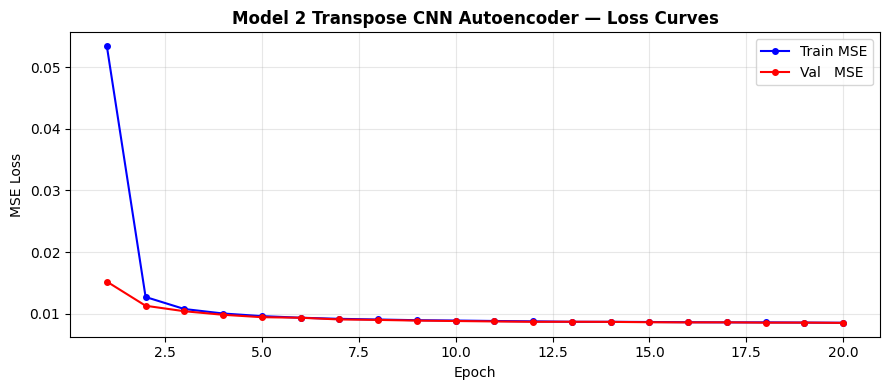

  Saved → model_2_transpose_cnn_autoencoder_loss.png


In [21]:
plot_loss(hist2, "Model 2 Transpose CNN Autoencoder")

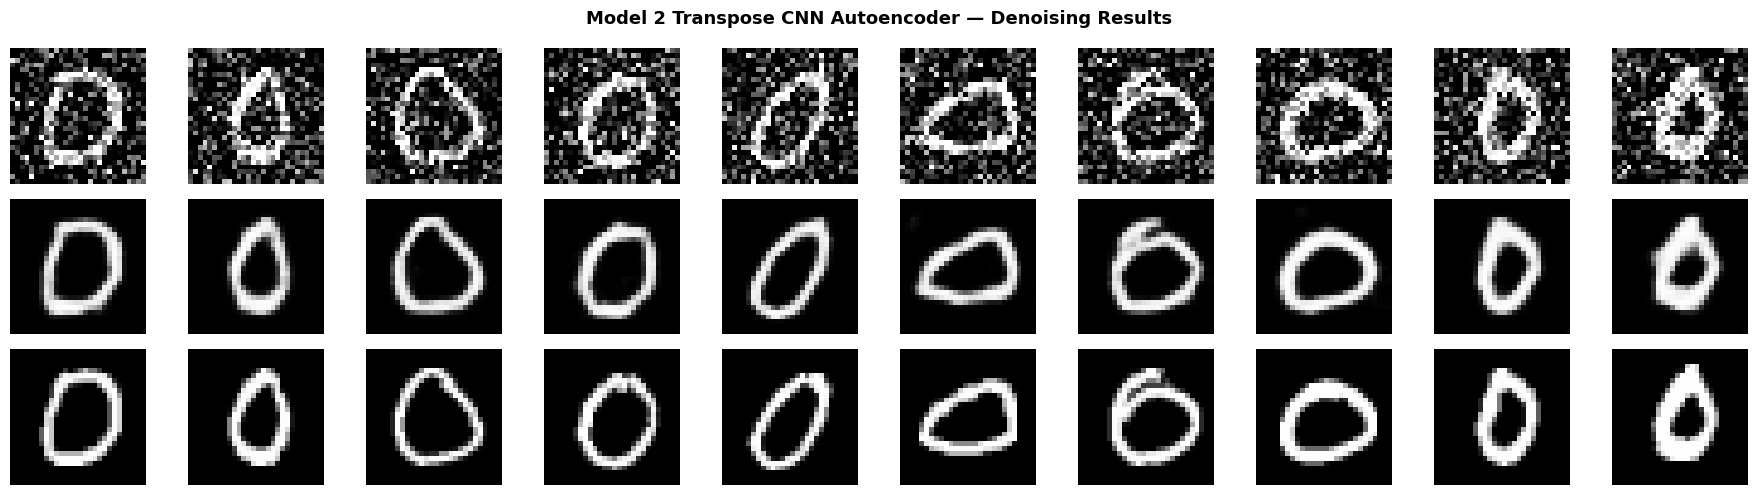

  Saved → model_2_transpose_cnn_autoencoder_results.png


In [22]:
show_denoising(m2, test_ld_cnn,
               name="Model 2 Transpose CNN Autoencoder", flat=False)

---
# 🔬 Model 3 — Upsampled CNN Autoencoder ⭐ (Best)

```
Encoder : Conv→Pool → Conv→Pool → Conv   (28→14→7,  bottleneck 4×7×7)
Decoder : Upsample+Conv → Upsample+Conv → Conv+Sigmoid  (7→14→28)
```

> 📌 *Bilinear upsampling + regular Conv2d eliminates checkerboard artifacts.*  
> Ref: Odena et al., *Deconvolution and Checkerboard Artifacts*, Distill (2016).

In [23]:
class UpsampledCNNAutoencoder(nn.Module):
    """
    Model 3 — Upsampled CNN Autoencoder.
    Decoder uses bilinear Upsample + Conv2d → no checkerboard.
    Input / output : (batch, 1, 28, 28)
    Bottleneck     : (batch, 4,  7,  7)
    """
    def __init__(self):
        super().__init__()

        # ── Encoder ──────────────────────────────────────────────────────
        self.enc1  = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(True))          # (1,28,28)→(32,28,28)
        self.pool1 = nn.MaxPool2d(2, 2)                 # →(32,14,14)

        self.enc2  = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(True))          # (32,14,14)→(16,14,14)
        self.pool2 = nn.MaxPool2d(2, 2)                 # →(16,7,7)

        self.enc3  = nn.Sequential(
            nn.Conv2d(16, 4, 3, padding=1),
            nn.BatchNorm2d(4), nn.ReLU(True))           # bottleneck →(4,7,7)

        # ── Decoder ──────────────────────────────────────────────────────
        self.up1   = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear",
                        align_corners=False),            # 7→14
            nn.Conv2d(4, 16, 3, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(True))

        self.up2   = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear",
                        align_corners=False),            # 14→28
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(True))

        self.final = nn.Sequential(
            nn.Conv2d(32, 1, 3, padding=1),             # (32,28,28)→(1,28,28)
            nn.Sigmoid())

        self.apply(init_weights)

    def encode(self, x):
        return self.enc3(self.pool2(self.enc2(self.pool1(self.enc1(x)))))

    def decode(self, z):
        return self.final(self.up2(self.up1(z)))

    def forward(self, x):
        return self.decode(self.encode(x))


m3    = UpsampledCNNAutoencoder()
dummy = torch.zeros(2, 1, 28, 28)
print(f"Input  : {dummy.shape}")
print(f"Latent : {m3.encode(dummy).shape}")
print(f"Output : {m3(dummy).shape}")
print(f"Params : {sum(p.numel() for p in m3.parameters()):,}")
print(m3)

Input  : torch.Size([2, 1, 28, 28])
Latent : torch.Size([2, 4, 7, 7])
Output : torch.Size([2, 1, 28, 28])
Params : 11,245
UpsampledCNNAutoencoder(
  (enc1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): Sequential(
    (0): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc3): Sequential(
    (0): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (up1): Sequential(
    (0): 

In [24]:
m3, hist3 = train_model(m3, train_ld_cnn, val_ld_cnn,
                         name="Model 3: Upsampled CNN Autoencoder")


════════════════════════════════════════════════════════════════
  Model 3: Upsampled CNN Autoencoder
  Trainable parameters : 11,245
════════════════════════════════════════════════════════════════


Epochs:   0%|                                        | 0/20 [00:00<?, ?ep/s]


  Best Val MSE : 0.008816


In [25]:
m3_test = evaluate(m3, test_ld_cnn, crit)
print(f"Model 3  Test MSE : {m3_test:.6f}")

Model 3  Test MSE : 0.008663


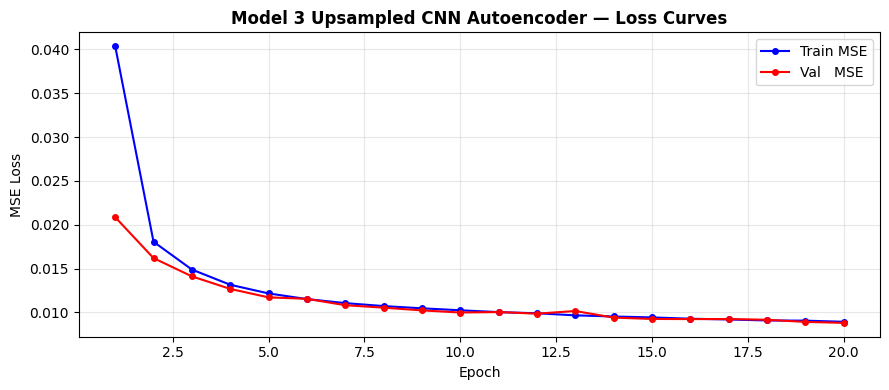

  Saved → model_3_upsampled_cnn_autoencoder_loss.png


In [26]:
plot_loss(hist3, "Model 3 Upsampled CNN Autoencoder")

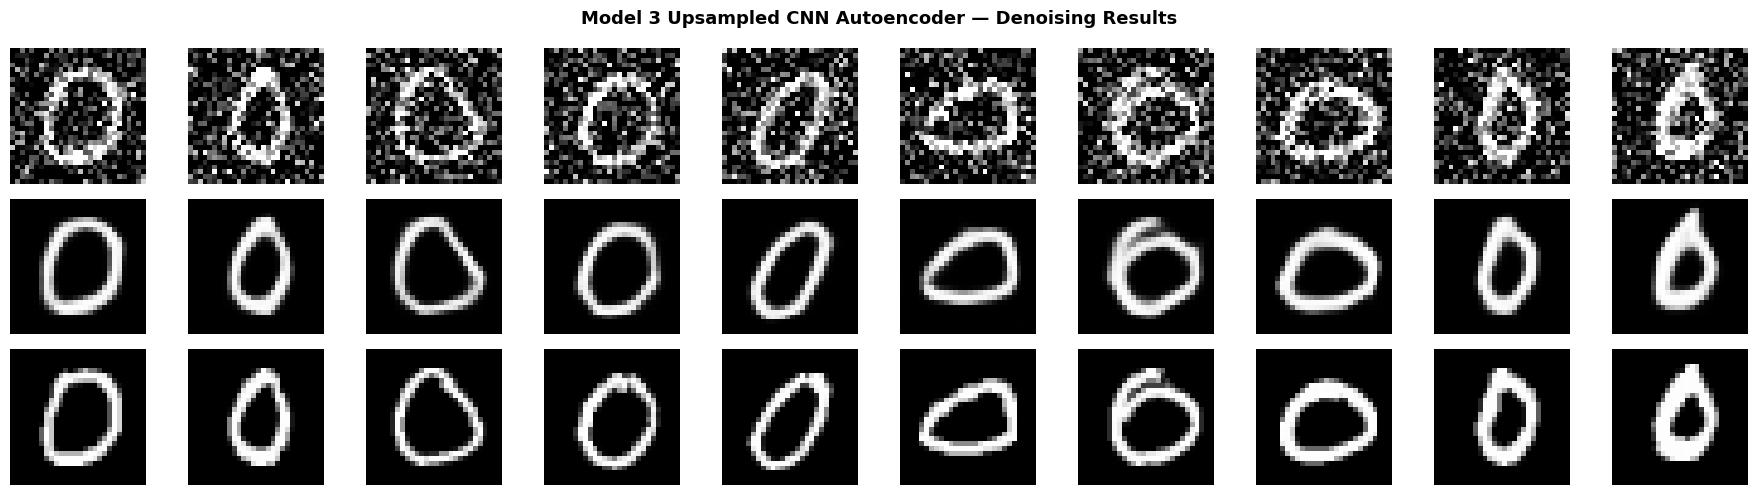

  Saved → model_3_upsampled_cnn_autoencoder_results.png


In [27]:
show_denoising(m3, test_ld_cnn,
               name="Model 3 Upsampled CNN Autoencoder", flat=False)

---
# 📈 Step 11 — Model Comparison

In [28]:
summary = pd.DataFrame({
    "Model": [
        "Model 1: FFNN",
        "Model 2: Transpose CNN",
        "Model 3: Upsampled CNN ⭐",
    ],
    "Parameters": [
        f"{sum(p.numel() for p in FFNNAutoencoder().parameters()):,}",
        f"{sum(p.numel() for p in TransposeCNNAutoencoder().parameters()):,}",
        f"{sum(p.numel() for p in UpsampledCNNAutoencoder().parameters()):,}",
    ],
    "Best Val MSE": [
        f"{min(hist1['val']):.6f}",
        f"{min(hist2['val']):.6f}",
        f"{min(hist3['val']):.6f}",
    ],
    "Test MSE": [
        f"{m1_test:.6f}",
        f"{m2_test:.6f}",
        f"{m3_test:.6f}",
    ],
    "Artifacts?": ["N/A", "Possible ⚠️", "None ✅"],
})

print("\n" + "═"*72)
print("  MODEL COMPARISON SUMMARY")
print("═"*72)
print(summary.to_string(index=False))
print("═"*72)


════════════════════════════════════════════════════════════════════════
  MODEL COMPARISON SUMMARY
════════════════════════════════════════════════════════════════════════
                   Model Parameters Best Val MSE Test MSE  Artifacts?
           Model 1: FFNN    484,944     0.013487 0.013103         N/A
  Model 2: Transpose CNN     10,053     0.008499 0.008372 Possible ⚠️
Model 3: Upsampled CNN ⭐     11,245     0.008816 0.008663      None ✅
════════════════════════════════════════════════════════════════════════


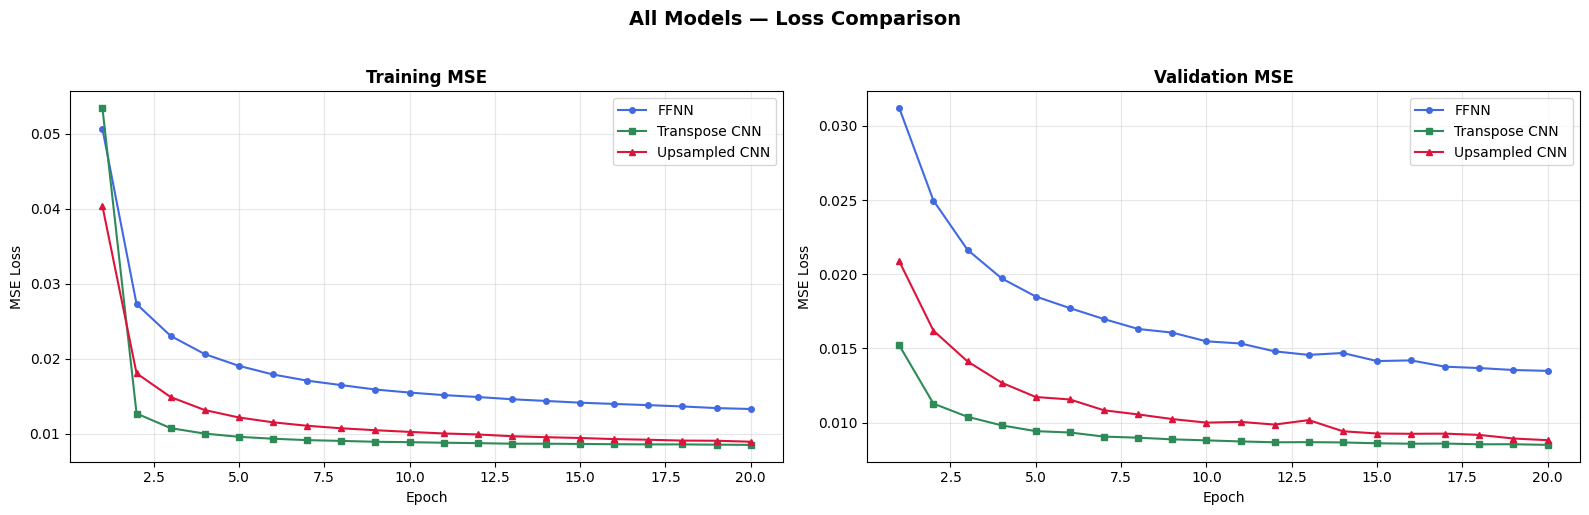

Saved → all_models_loss.png


In [29]:
# ── Combined loss curves ───────────────────────────────────────────────────────
ep = range(1, EPOCHS + 1)
configs = [
    ("FFNN",          hist1, "royalblue", "o"),
    ("Transpose CNN", hist2, "seagreen",  "s"),
    ("Upsampled CNN", hist3, "crimson",   "^"),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
for label, h, col, mk in configs:
    ax1.plot(ep, h["train"], color=col, marker=mk, ms=4, label=label)
    ax2.plot(ep, h["val"],   color=col, marker=mk, ms=4, label=label)

for ax, title in [(ax1, "Training MSE"), (ax2, "Validation MSE")]:
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
    ax.set_title(title, fontweight="bold")
    ax.legend(); ax.grid(alpha=0.3)

fig.suptitle("All Models — Loss Comparison", fontsize=14,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("all_models_loss.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → all_models_loss.png")

---
# 🎨 Step 12 — Side-by-Side Visual Comparison (All Models)

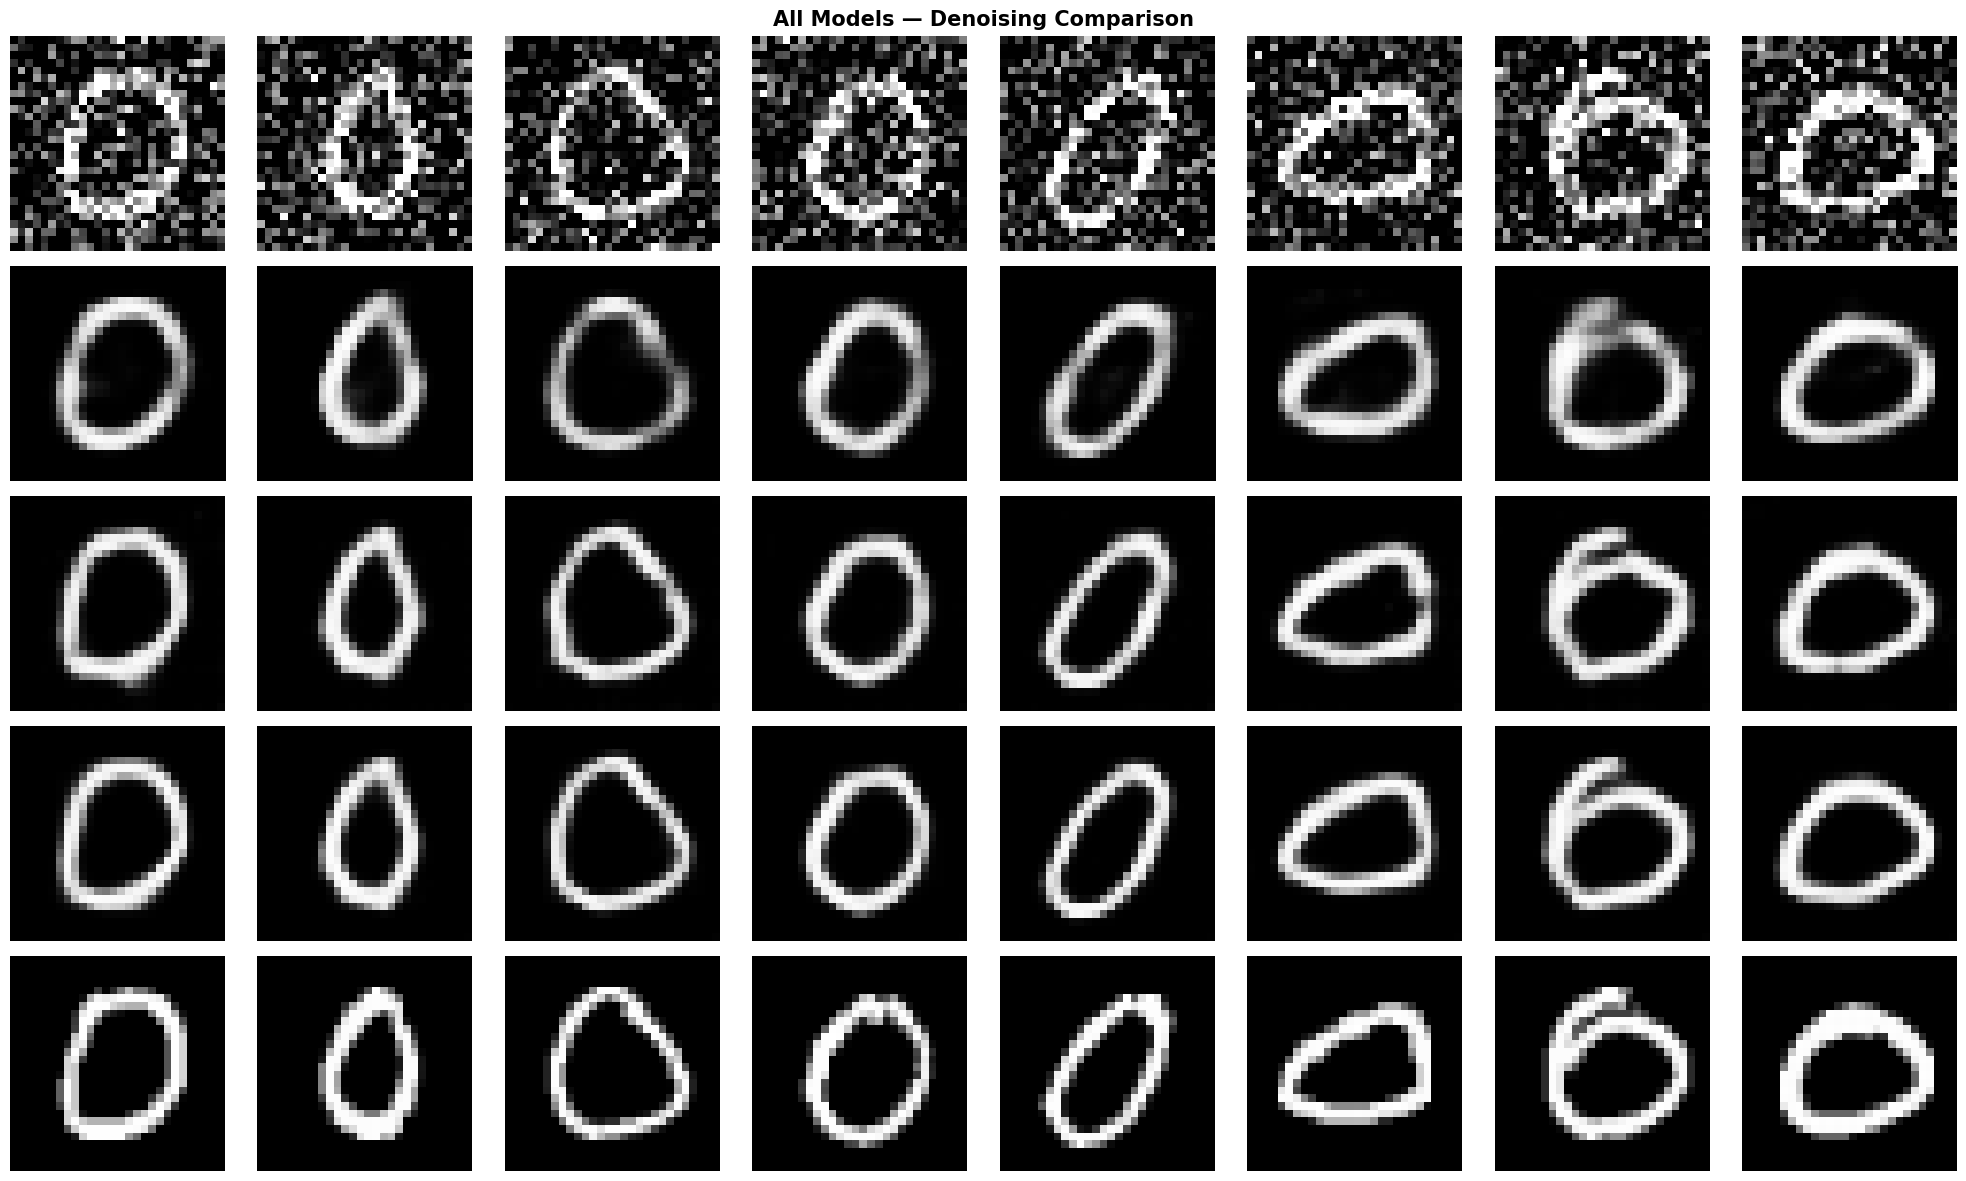

Saved → all_models_visual.png


In [30]:
@torch.no_grad()
def compare_all(m1, m2, m3, n=8):
    for m in [m1, m2, m3]:
        m.eval()

    batch      = next(iter(test_ld_flat))
    noisy_flat = batch[0][:n].to(device)          # (n, 784)
    clean_flat = batch[1][:n].cpu()
    noisy_cnn  = noisy_flat.view(n, 1, 28, 28)

    out1 = m1(noisy_flat).cpu()
    out2 = m2(noisy_cnn ).cpu()
    out3 = m3(noisy_cnn ).cpu()

    rows = [
        (noisy_flat, "Noisy Input",                True),
        (out1,       "Model 1 — FFNN",             True),
        (out2,       "Model 2 — Transpose CNN",    False),
        (out3,       "Model 3 — Upsampled CNN ⭐", False),
        (clean_flat, "Clean Target",               True),
    ]

    fig, axes = plt.subplots(5, n, figsize=(20, 12))
    fig.suptitle("All Models — Denoising Comparison",
                 fontsize=15, fontweight="bold")
    for r, (imgs, title, is_flat) in enumerate(rows):
        for c in range(n):
            img = imgs[c].view(28,28) if is_flat else imgs[c].squeeze(0)
            axes[r, c].imshow(img.numpy(), cmap="gray", vmin=0, vmax=1)
            axes[r, c].axis("off")
        axes[r, 0].set_ylabel(title, fontsize=9, fontweight="bold")

    plt.tight_layout()
    plt.savefig("all_models_visual.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved → all_models_visual.png")

compare_all(m1, m2, m3, n=8)

---
# 🔢 Step 13 — Latent Space Visualisation (t-SNE)

── FFNN latent space ──
t-SNE on 3000 samples, latent dim=64 …


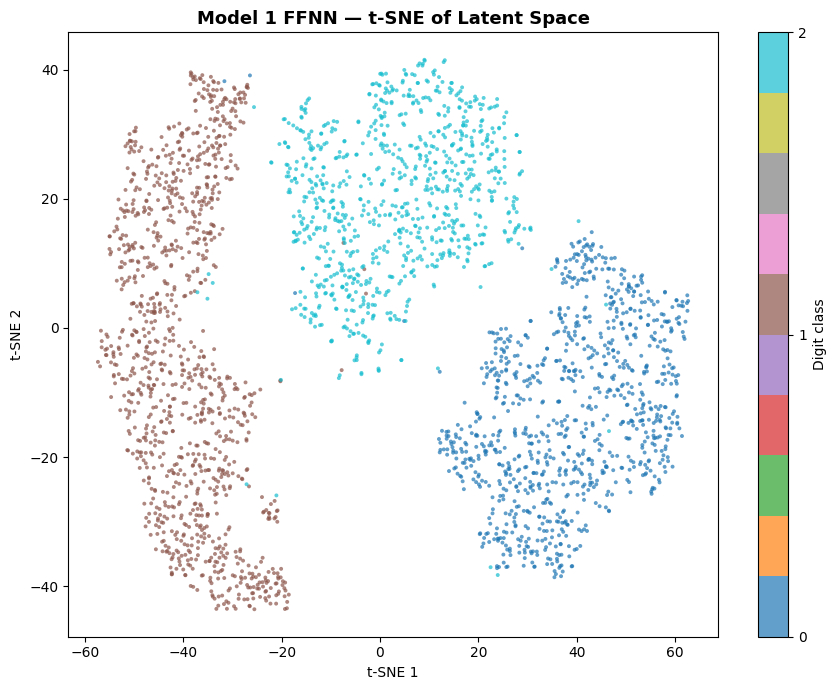

Saved → model_1_ffnn_tsne.png


In [31]:
from sklearn.manifold import TSNE

@torch.no_grad()
def tsne_plot(model, loader, n_samples=3000, name="Model"):
    model.eval()
    latents, lbls, seen = [], [], 0
    for batch in loader:
        noisy = batch[0].to(device)
        lbl   = batch[2] if len(batch) == 3 else torch.zeros(noisy.size(0))
        z = model.encode(noisy).cpu().numpy().reshape(noisy.size(0), -1)
        latents.append(z)
        lbls.append(lbl.numpy() if hasattr(lbl, "numpy") else np.array(lbl))
        seen += noisy.size(0)
        if seen >= n_samples:
            break

    Z = np.vstack(latents)[:n_samples]
    L = np.concatenate(lbls)[:n_samples]

    print(f"t-SNE on {len(Z)} samples, latent dim={Z.shape[1]} …")
    emb = TSNE(n_components=2, random_state=SEED,
               perplexity=30, n_iter=1000).fit_transform(Z)

    fig, ax = plt.subplots(figsize=(9, 7))
    sc = ax.scatter(emb[:,0], emb[:,1], c=L, cmap="tab10",
                    alpha=0.7, s=8, linewidths=0)
    plt.colorbar(sc, ax=ax, ticks=range(10), label="Digit class")
    ax.set_title(f"{name} — t-SNE of Latent Space",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
    plt.tight_layout()
    fname = name.replace(" ","_").lower() + "_tsne.png"
    plt.savefig(fname, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fname}")

print("── FFNN latent space ──")
tsne_plot(m1, test_ld_flat, n_samples=3000, name="Model 1 FFNN")

── Upsampled CNN latent space ──
t-SNE on 3000 samples, latent dim=196 …


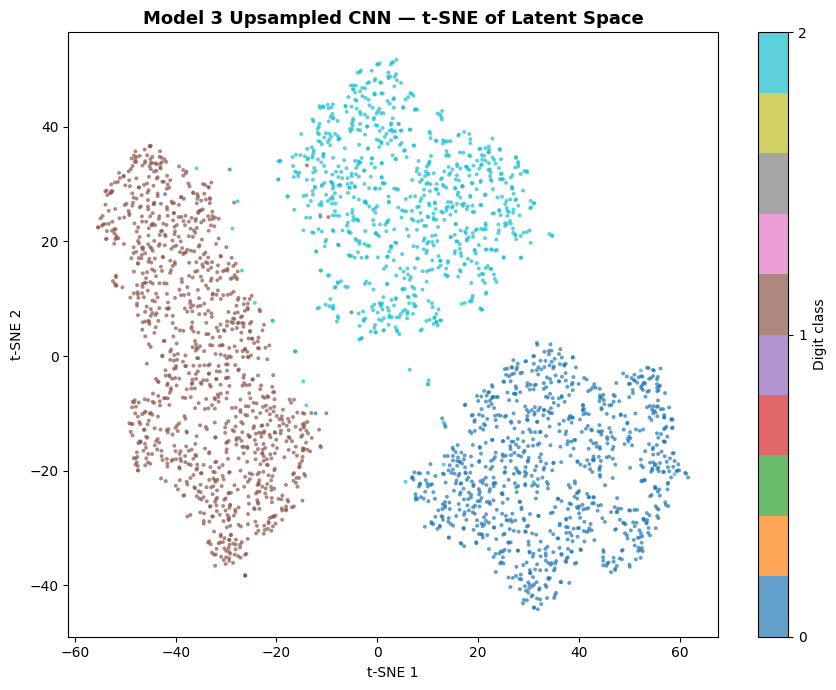

Saved → model_3_upsampled_cnn_tsne.png


In [32]:
print("── Upsampled CNN latent space ──")
tsne_plot(m3, test_ld_cnn, n_samples=3000, name="Model 3 Upsampled CNN")

---
# 📉 Step 14 — Noise Sensitivity Analysis

In [33]:
NOISE_SWEEP = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

@torch.no_grad()
def sweep_noise(model, flat, tag):
    model.eval()
    losses = []
    for sigma in NOISE_SWEEP:
        _, _, tl = make_loaders(flat=flat, noise_factor=sigma, batch_size=256)
        losses.append(evaluate(model, tl, nn.MSELoss()))
        print(f"  [{tag}] σ={sigma:.1f}  MSE={losses[-1]:.6f}")
    return losses

print("▶ Model 1 — FFNN")
sens1 = sweep_noise(m1, flat=True,  tag="FFNN")

print("\n▶ Model 3 — Upsampled CNN")
sens3 = sweep_noise(m3, flat=False, tag="Upsampled CNN")

▶ Model 1 — FFNN
  Train : 48,000 samples  →  188 batches
  Val   : 12,000 samples  →   47 batches
  Test  : 10,000 samples  →   40 batches
  [FFNN] σ=0.0  MSE=0.011052
  Train : 48,000 samples  →  188 batches
  Val   : 12,000 samples  →   47 batches
  Test  : 10,000 samples  →   40 batches
  [FFNN] σ=0.1  MSE=0.010551
  Train : 48,000 samples  →  188 batches
  Val   : 12,000 samples  →   47 batches
  Test  : 10,000 samples  →   40 batches
  [FFNN] σ=0.2  MSE=0.010541
  Train : 48,000 samples  →  188 batches
  Val   : 12,000 samples  →   47 batches
  Test  : 10,000 samples  →   40 batches
  [FFNN] σ=0.3  MSE=0.011275
  Train : 48,000 samples  →  188 batches
  Val   : 12,000 samples  →   47 batches
  Test  : 10,000 samples  →   40 batches
  [FFNN] σ=0.4  MSE=0.013144
  Train : 48,000 samples  →  188 batches
  Val   : 12,000 samples  →   47 batches
  Test  : 10,000 samples  →   40 batches
  [FFNN] σ=0.5  MSE=0.016177
  Train : 48,000 samples  →  188 batches
  Val   : 12,000 samples  →   

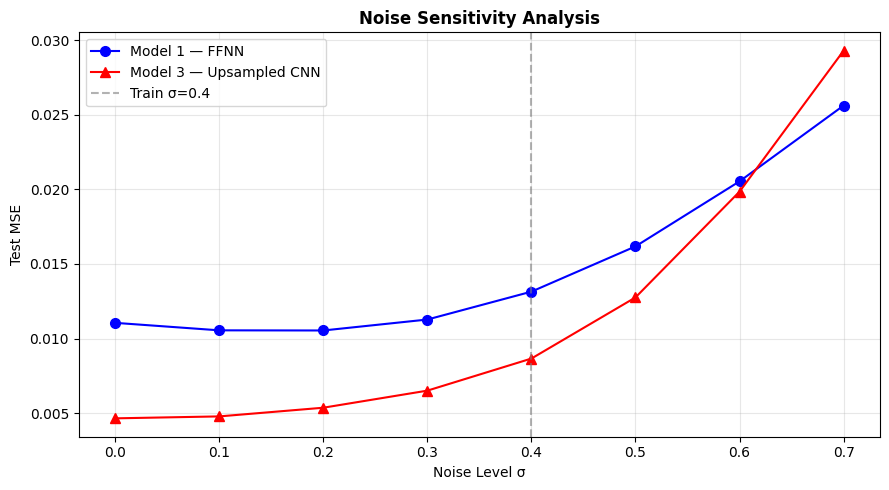

Saved → noise_sensitivity.png


In [34]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(NOISE_SWEEP, sens1, "b-o", ms=7, label="Model 1 — FFNN")
ax.plot(NOISE_SWEEP, sens3, "r-^", ms=7, label="Model 3 — Upsampled CNN")
ax.axvline(NOISE_FACTOR, color="gray", ls="--", alpha=0.6,
           label=f"Train σ={NOISE_FACTOR}")
ax.set_xlabel("Noise Level σ"); ax.set_ylabel("Test MSE")
ax.set_title("Noise Sensitivity Analysis", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("noise_sensitivity.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → noise_sensitivity.png")

---
# 💾 Step 15 — Save Models

In [35]:
os.makedirs("saved_models", exist_ok=True)

for model, fname, tag in [
    (m1, "saved_models/m1_ffnn.pt",          "FFNN"),
    (m2, "saved_models/m2_transpose_cnn.pt", "Transpose CNN"),
    (m3, "saved_models/m3_upsampled_cnn.pt", "Upsampled CNN"),
]:
    torch.save({"state_dict": model.state_dict(),
                "class":      model.__class__.__name__}, fname)
    mb = os.path.getsize(fname) / 1024**2
    print(f"✅  {tag:<18} → {fname}  ({mb:.2f} MB)")

✅  FFNN               → saved_models/m1_ffnn.pt  (1.85 MB)
✅  Transpose CNN      → saved_models/m2_transpose_cnn.pt  (0.05 MB)
✅  Upsampled CNN      → saved_models/m3_upsampled_cnn.pt  (0.06 MB)


---
# 🔄 Step 16 — Load & Single-Image Inference Demo

✅  Loaded UpsampledCNNAutoencoder from disk.


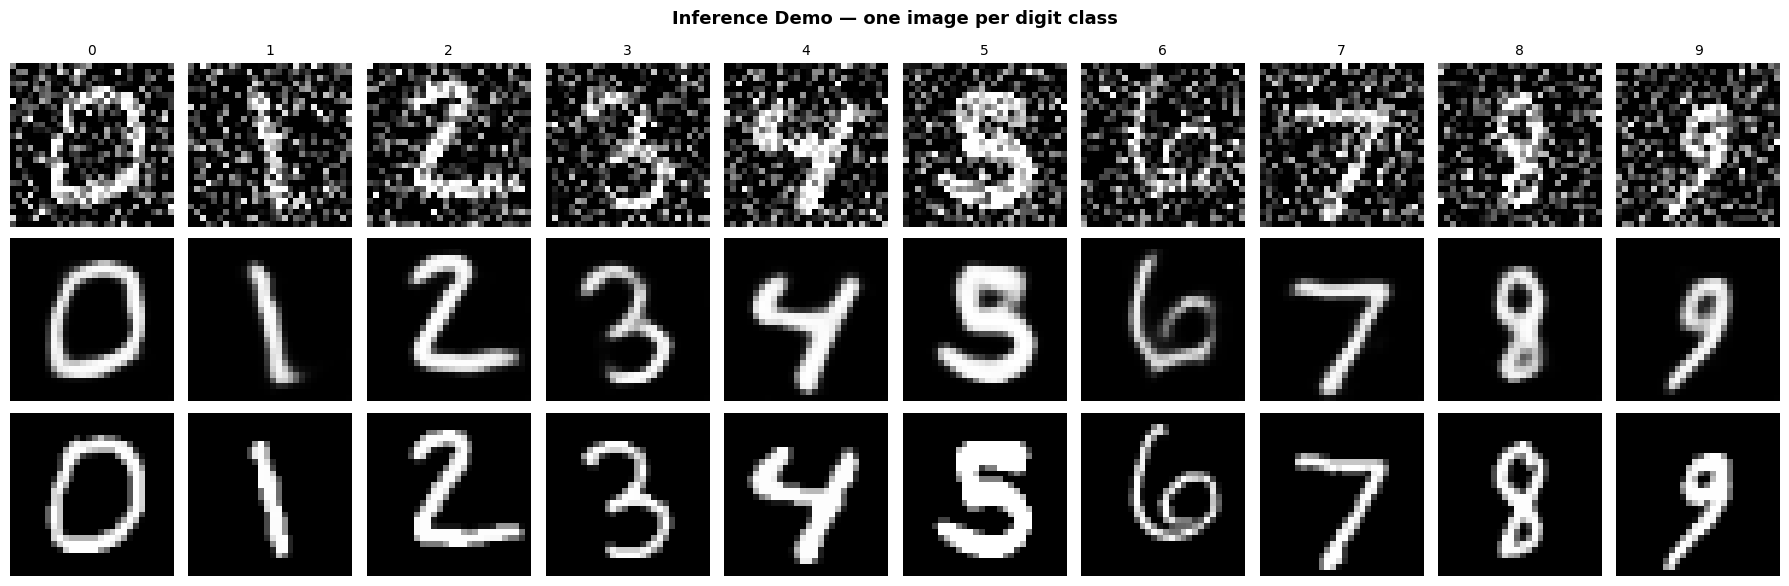

Saved → inference_demo.png


In [36]:
# ── Reload best model from disk ───────────────────────────────────────────────
ckpt       = torch.load("saved_models/m3_upsampled_cnn.pt", map_location=device)
best_model = UpsampledCNNAutoencoder().to(device)
best_model.load_state_dict(ckpt["state_dict"])
best_model.eval()
print(f"✅  Loaded {ckpt['class']} from disk.")


@torch.no_grad()
def denoise_single(model, clean_flat, sigma=0.4):
    """Denoise one image. clean_flat: ndarray (784,) in [0,1]"""
    noisy = np.clip(
        clean_flat + np.random.normal(0, sigma, 784).astype(np.float32), 0, 1
    )
    inp = torch.from_numpy(noisy).view(1, 1, 28, 28).to(device)
    out = model(inp).cpu().squeeze().numpy()
    return (noisy.reshape(28,28),
            out.reshape(28,28),
            clean_flat.reshape(28,28))


# ── Demo: one image per digit class ───────────────────────────────────────────
fig, axes = plt.subplots(3, 10, figsize=(18, 6))
fig.suptitle("Inference Demo — one image per digit class",
             fontsize=13, fontweight="bold")

for digit in range(10):
    idx = np.where(test_labels == digit)[0][0]
    noisy_img, denoised_img, clean_img = denoise_single(best_model, test_images[idx])
    for row, (img, lbl) in enumerate([
        (noisy_img,    "Noisy"),
        (denoised_img, "Denoised"),
        (clean_img,    "Clean")
    ]):
        axes[row, digit].imshow(img, cmap="gray", vmin=0, vmax=1)
        axes[row, digit].set_title(str(digit) if row == 0 else "", fontsize=10)
        axes[row, digit].axis("off")
        if digit == 0:
            axes[row, digit].set_ylabel(lbl, fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("inference_demo.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → inference_demo.png")

# 🏁 Final Summary

| Model | Parameters | Best Validation MSE | Test MSE | Artifacts | Overall |
|:------|-----------:|--------------------:|---------:|:---------:|:-------:|
| FFNN Autoencoder | 484,944 | 0.013487 | 0.013103 | N/A | Baseline |
| Transpose CNN Autoencoder | 10,053 | **0.008499** | **0.008372** | Possible ⚠️ | Best Numerical Performance |
| ⭐ Upsampled CNN Autoencoder | 11,245 | 0.008816 | 0.008663 | None ✅ | Best Overall Choice |

## Key Takeaways

- **CNN-based autoencoders significantly outperform the FFNN autoencoder** for image denoising while using far fewer parameters.
- **Transpose CNN achieved the lowest Validation and Test MSE**, indicating the best numerical reconstruction accuracy.
- **Upsampled CNN produced nearly identical reconstruction accuracy while eliminating checkerboard artifacts**, resulting in cleaner and more visually appealing reconstructed images.
- **ReduceLROnPlateau** improved training by automatically reducing the learning rate when validation performance stopped improving.
- **MSE Loss** proved effective for pixel-wise image reconstruction and denoising.
- **t-SNE visualization** demonstrated that the learned latent representations capture meaningful image features even without supervision.

## Final Conclusion

All three autoencoders successfully learned to denoise MNIST images. The FFNN model served as a strong baseline but produced the highest reconstruction error despite having the largest number of trainable parameters. The Transpose CNN achieved the **lowest Test MSE (0.008372)**, making it the most accurate model numerically. However, the **Upsampled CNN** achieved almost identical performance (**Test MSE = 0.008663**) while completely avoiding checkerboard artifacts. Therefore, considering both quantitative performance and visual reconstruction quality, **the Upsampled CNN is the preferred architecture for this image denoising task.**